# EDA — Student Dropout Risk

**Purpose.** This notebook produces *decisions*, not just plots. Six questions, each
with a consequence for how the pipeline gets built. The answers are confirmed against
the real UCI 697 data and feed directly into the schema (Step 4), the features and
preprocessing (Step 5), and the metric code (Step 6).

Companion docs: `problem_statement.md`, `architecture.md`.

**How to use:** run top to bottom. Where a cell prints a **DECISION** line, that is the
fact we carry forward. Paste those lines back to calibrate the code that follows.

In [3]:
import os
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
print("working dir:", os.getcwd())
print("file exists:", os.path.exists("data/raw/dropout.csv"))

working dir: /Users/karthi/Desktop/dropout_risk
file exists: True


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

RAW = "data/raw/dropout.csv"
df = pd.read_csv(RAW)
print("shape:", df.shape)
df.head()

shape: (4424, 38)


,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target,dropout
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout,1
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate,0
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout,1
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate,0
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate,0


## Q0 — Sanity: does the snapshot match what ingestion reported?

Confirms we are analysing the same 4,424 rows with the same base rate, before drawing
any conclusions from them.

In [5]:
assert df.shape[0] == 4424, f"unexpected row count: {df.shape[0]}"
print("rows:", len(df))
print("cols:", df.shape[1])
print()
print("original target:")
print(df["Target"].value_counts())
print()
print(f"binary base rate (dropout=1): {df['dropout'].mean():.4f}")

rows: 4424
cols: 38

original target:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

binary base rate (dropout=1): 0.3212


## Q1 — Nulls

**Consequence.** The dataset is documented as complete. If that holds, the Pandera
schema in Step 4 treats *any* null as corruption to reject — not a value to impute.
If nulls exist, we need an imputation strategy instead.

In [6]:
nulls = df.isnull().sum()
total_nulls = nulls.sum()
print(f"total nulls across all columns: {total_nulls}")
if total_nulls > 0:
    print(nulls[nulls > 0])
    print("\nDECISION: nulls present -> schema must allow + impute")
else:
    print("\nDECISION: zero nulls -> schema rejects any null as corruption")

total nulls across all columns: 0

DECISION: zero nulls -> schema rejects any null as corruption


## Q2 — Column inventory and dtypes

**Consequence.** We need the *exact* column-name strings for the semester-1 curricular
units and the six slice attributes, because preprocessing code references them literally.
The documentation uses one spelling; the CSV may differ (e.g. `Nacionality` is a known
misspelling in this dataset).

In [7]:
for i, (c, t) in enumerate(zip(df.columns, df.dtypes)):
    print(f"{i:2d}  {str(t):8s}  {c}")

 0  int64     Marital Status
 1  int64     Application mode
 2  int64     Application order
 3  int64     Course
 4  int64     Daytime/evening attendance
 5  int64     Previous qualification
 6  float64   Previous qualification (grade)
 7  int64     Nacionality
 8  int64     Mother's qualification
 9  int64     Father's qualification
10  int64     Mother's occupation
11  int64     Father's occupation
12  float64   Admission grade
13  int64     Displaced
14  int64     Educational special needs
15  int64     Debtor
16  int64     Tuition fees up to date
17  int64     Gender
18  int64     Scholarship holder
19  int64     Age at enrollment
20  int64     International
21  int64     Curricular units 1st sem (credited)
22  int64     Curricular units 1st sem (enrolled)
23  int64     Curricular units 1st sem (evaluations)
24  int64     Curricular units 1st sem (approved)
25  float64   Curricular units 1st sem (grade)
26  int64     Curricular units 1st sem (without evaluations)
27  int64     Curr

### Locate the key column groups by pattern

If any list below is empty, the naming differs from what we assumed and the config
must be updated before Step 5.

In [8]:
sem1_cols = [c for c in df.columns if "1st sem" in c]
sem2_cols = [c for c in df.columns if "2nd sem" in c]

print("SEMESTER 1 columns (KEEP):")
for c in sem1_cols: print("  ", c)
print("\nSEMESTER 2 columns (DROP as leakage):")
for c in sem2_cols: print("  ", c)

print(f"\nDECISION: drop {len(sem2_cols)} sem-2 columns; "
      f"keep {len(sem1_cols)} sem-1 columns")

SEMESTER 1 columns (KEEP):
   Curricular units 1st sem (credited)
   Curricular units 1st sem (enrolled)
   Curricular units 1st sem (evaluations)
   Curricular units 1st sem (approved)
   Curricular units 1st sem (grade)
   Curricular units 1st sem (without evaluations)

SEMESTER 2 columns (DROP as leakage):
   Curricular units 2nd sem (credited)
   Curricular units 2nd sem (enrolled)
   Curricular units 2nd sem (evaluations)
   Curricular units 2nd sem (approved)
   Curricular units 2nd sem (grade)
   Curricular units 2nd sem (without evaluations)

DECISION: drop 6 sem-2 columns; keep 6 sem-1 columns


In [9]:
# The six slice attributes named in the problem statement.
expected_slices = ["Gender", "Age at enrollment", "International",
                   "Displaced", "Scholarship holder", "Debtor"]
print("Slice attribute check:")
for s in expected_slices:
    print(f"  {'FOUND  ' if s in df.columns else 'MISSING'}  {s}")

missing = [s for s in expected_slices if s not in df.columns]
print(f"\nDECISION: {'all slice columns present' if not missing else 'FIX config: ' + str(missing)}")

Slice attribute check:
  FOUND    Gender
  FOUND    Age at enrollment
  FOUND    International
  FOUND    Displaced
  FOUND    Scholarship holder
  FOUND    Debtor

DECISION: all slice columns present


## Q3 — Categorical cardinalities

**Consequence.** This is the architecture doc's hard checkpoint. High-cardinality
categoricals (parental occupation/qualification, nationality) blow up the one-hot
logistic branch. This cell confirms the real level counts, sets the `top_k` capping,
and tells us the true one-hot width — validating or correcting the ~125-column estimate.

In [10]:
# Columns that are categorical despite being integer-encoded.
categorical_candidates = [
    "Marital status", "Application mode", "Application order", "Course",
    "Daytime/evening attendance", "Previous qualification", "Nacionality",
    "Mother's qualification", "Father's qualification",
    "Mother's occupation", "Father's occupation",
    "Displaced", "Educational special needs", "Debtor",
    "Tuition fees up to date", "Gender", "Scholarship holder", "International",
]
present = [c for c in categorical_candidates if c in df.columns]

card = pd.DataFrame({
    "column": present,
    "n_unique": [df[c].nunique() for c in present],
}).sort_values("n_unique", ascending=False).reset_index(drop=True)
print(card.to_string(index=False))

high = card[card.n_unique > 10]["column"].tolist()
low = card[card.n_unique <= 10]["column"].tolist()
print(f"\nHIGH cardinality (>10, cap with top_k+OTHER): {high}")
print(f"LOW cardinality (<=10, one-hot directly):     {low}")

                    column  n_unique
       Father's occupation        46
    Father's qualification        34
       Mother's occupation        32
    Mother's qualification        29
               Nacionality        21
          Application mode        18
    Previous qualification        17
                    Course        17
         Application order         8
Daytime/evening attendance         2
                 Displaced         2
 Educational special needs         2
                    Debtor         2
   Tuition fees up to date         2
                    Gender         2
        Scholarship holder         2
             International         2

HIGH cardinality (>10, cap with top_k+OTHER): ["Father's occupation", "Father's qualification", "Mother's occupation", "Mother's qualification", 'Nacionality', 'Application mode', 'Previous qualification', 'Course']
LOW cardinality (<=10, one-hot directly):     ['Application order', 'Daytime/evening attendance', 'Displaced', 'Educa

In [11]:
# Estimate true one-hot width for the logistic branch, with top-10 capping.
TOP_K = 10
def capped_width(col):
    u = df[col].nunique()
    return min(u, TOP_K) + (1 if u > TOP_K else 0)  # +1 for OTHER bucket

oh_width = sum(capped_width(c) for c in present)
numeric_cols = [c for c in df.columns
                if c not in present and c not in ("Target", "dropout")]
print(f"one-hot width (categoricals, top-{TOP_K} capped): {oh_width}")
print(f"numeric/passthrough columns:                    {len(numeric_cols)}")
print(f"\nDECISION: logistic design matrix ~= {oh_width + len(numeric_cols)} columns")
print(f"          (GBM sees ~36 via native categorical handling)")

one-hot width (categoricals, top-10 capped): 112
numeric/passthrough columns:                    19

DECISION: logistic design matrix ~= 131 columns
          (GBM sees ~36 via native categorical handling)


## Q4 — Macro indicators: signal or cohort proxy?

**Consequence.** If Unemployment/Inflation/GDP take only a handful of distinct values,
they are effectively an enrollment-year label, not economic signal. That changes how we
interpret their feature importance later — near-zero importance would then be *expected*,
not surprising.

In [12]:
macro = [c for c in ["Unemployment rate", "Inflation rate", "GDP"] if c in df.columns]
for c in macro:
    print(f"{c}: {df[c].nunique()} distinct values -> {sorted(df[c].unique())}")
print(f"\nDECISION: if each has <15 distinct values, treat as cohort-year proxy")

Unemployment rate: 10 distinct values -> [np.float64(7.6), np.float64(8.9), np.float64(9.4), np.float64(10.8), np.float64(11.1), np.float64(12.4), np.float64(12.7), np.float64(13.9), np.float64(15.5), np.float64(16.2)]
Inflation rate: 9 distinct values -> [np.float64(-0.8), np.float64(-0.3), np.float64(0.3), np.float64(0.5), np.float64(0.6), np.float64(1.4), np.float64(2.6), np.float64(2.8), np.float64(3.7)]
GDP: 10 distinct values -> [np.float64(-4.06), np.float64(-3.12), np.float64(-1.7), np.float64(-0.92), np.float64(0.32), np.float64(0.79), np.float64(1.74), np.float64(1.79), np.float64(2.02), np.float64(3.51)]

DECISION: if each has <15 distinct values, treat as cohort-year proxy


## Q5 — Does semester-1 performance actually separate dropouts?

**Consequence.** The entire premise is that early academic signal predicts dropout. If
`sem1_pass_rate` does not separate the classes, the project's framing is wrong and we
need to know now, not after building a pipeline. This also previews baseline 2.

sem1_pass_rate by outcome (0=stayed, 1=dropout):
             mean    median       std
dropout                              
0        0.846416  1.000000  0.248971
1        0.383994  0.333333  0.373138


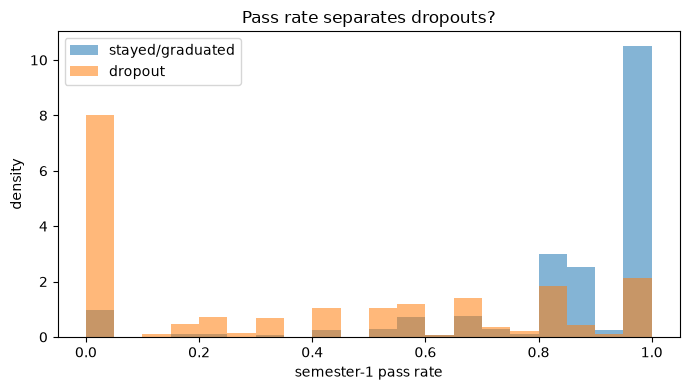


DECISION: mean gap = 0.462. Strong separation, premise holds.


In [13]:
enr = "Curricular units 1st sem (enrolled)"
app = "Curricular units 1st sem (approved)"

if enr in df.columns and app in df.columns:
    pass_rate = np.where(df[enr] > 0, df[app] / df[enr].replace(0, np.nan), 0.0)
    df["_sem1_pass_rate"] = pd.Series(pass_rate).fillna(0.0)

    by = df.groupby("dropout")["_sem1_pass_rate"].agg(["mean", "median", "std"])
    print("sem1_pass_rate by outcome (0=stayed, 1=dropout):")
    print(by)

    fig, ax = plt.subplots(figsize=(7, 4))
    for k, label in [(0, "stayed/graduated"), (1, "dropout")]:
        ax.hist(df.loc[df.dropout == k, "_sem1_pass_rate"],
                bins=20, alpha=0.55, label=label, density=True)
    ax.set_xlabel("semester-1 pass rate"); ax.set_ylabel("density")
    ax.legend(); ax.set_title("Pass rate separates dropouts?")
    plt.tight_layout(); plt.show()

    sep = by.loc[0, "mean"] - by.loc[1, "mean"]
    print(f"\nDECISION: mean gap = {sep:.3f}. "
          f"{'Strong separation, premise holds.' if sep > 0.2 else 'Weak — investigate.'}")
else:
    print("MISSING sem-1 columns — check names in Q2 output")

### Baseline 2 preview: how good is the pass-rate rule alone?

Ranks students by ascending pass rate, flags the worst 10%, and measures precision.
This is the number the model must beat. Seeing it now sets expectations.

In [14]:
k_percent = 0.10
k = int(np.ceil(k_percent * len(df)))
ranked = df.sort_values("_sem1_pass_rate", ascending=True)  # worst first
top_k = ranked.head(k)
precision_at_k = top_k["dropout"].mean()
base_rate = df["dropout"].mean()

print(f"k = top {k_percent:.0%} = {k} students")
print(f"pass-rate baseline precision@10%: {precision_at_k:.3f}")
print(f"base rate:                        {base_rate:.3f}")
print(f"lift:                             {precision_at_k / base_rate:.2f}x")
print(f"\nDECISION: model must beat precision@10% = {precision_at_k:.3f} to justify itself")

k = top 10% = 443 students
pass-rate baseline precision@10%: 0.810
base rate:                        0.321
lift:                             2.52x

DECISION: model must beat precision@10% = 0.810 to justify itself


## Q6 — Do the engineered candidates duplicate each other?

**Consequence.** `sem1_eval_rate` and `sem1_unevaluated_ratio` may just echo
`sem1_pass_rate`. If correlations are very high, some engineered features are redundant
and the ablation flag (`features.use_engineered`) will show no benefit — worth predicting
before the training runs.

In [15]:
enrolled = "Curricular units 1st sem (enrolled)"
approved = "Curricular units 1st sem (approved)"
evals    = "Curricular units 1st sem (evaluations)"
noeval   = "Curricular units 1st sem (without evaluations)"

e = df[enrolled].replace(0, np.nan)
cand = pd.DataFrame({
    "pass_rate":        (df[approved] / e).fillna(0),
    "eval_rate":        (df[evals] / e).fillna(0),
    "unevaluated_ratio":(df[noeval] / e).fillna(0),
})
print("correlation among engineered candidates:")
print(cand.corr().round(2))
print("\ncorrelation with target:")
for c in cand.columns:
    print(f"  {c:18s} {np.corrcoef(cand[c], df['dropout'])[0,1]:+.3f}")
print("\nDECISION: flag any pair with |r|>0.9 as redundant")

correlation among engineered candidates:
                   pass_rate  eval_rate  unevaluated_ratio
pass_rate               1.00       0.18              -0.14
eval_rate               0.18       1.00               0.18
unevaluated_ratio      -0.14       0.18               1.00

correlation with target:
  pass_rate          -0.591
  eval_rate          -0.022
  unevaluated_ratio  +0.081

DECISION: flag any pair with |r|>0.9 as redundant


## Summary of decisions

Fill this in from the DECISION lines above and carry it into Steps 4–6:

| # | Question | Decision |
|---|----------|----------|
| 1 | Nulls | zero nulls -> schema rejects any null as corruption|
| 2 | Sem-2 cols to drop / slice cols present |drop 6 sem-2 columns; keep 6 sem-1 columns all slice columns present |
| 3 | High-cardinality cols + one-hot width |logistic design matrix ~= 131 columns |
| 4 | Macro indicators = cohort proxy? | if each has <15 distinct values, treat as cohort-year proxy|
| 5 | Pass-rate separates? Baseline precision@10% | mean gap = 0.462. Strong separation, premise holds.model must beat precision@10% = 0.810 to justify itself|
| 6 | Redundant engineered features? |flag any pair with r:>0.9 as redundant |

These become the schema rules, the preprocessing config, and the baseline target number.